<a href="https://colab.research.google.com/github/KP11Rehesha/MachineLearning_Labs/blob/main/lab1_machineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна Робота 1
Використання алгоритму кластеризації K-Means для аналізу даних у Python

Виконав студент Регеша Олександр КП-51мн

2026

## Завдання до лабораторної роботи 1

У частині 1 потрібно виконати кластеризацію клієнтів банку для надання
позики різного типу на основі даних про цих клієнтів, надати відповіді на
поставлені питання у ході виконання програмного коду.
У частині 2 потрібно реалізувати алгоритми кластеризації k-means та
k-means++ для ініціалізації центроїдів у Python, а також побудувати криву
ліктя, щоб визначити, яка повинна бути потрібна кількість кластерів для
вказаного набору даних. Потрібно надати відповіді на поставлені питання у
ході виконання програмного коду та пояснити отриманий результат.

In [1]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt

#Частина 1

## Імпорт бібліотек та завантаження даних

In [3]:
data = pd.read_csv('clustering.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


## Візуалізація початкових даних

Ми отримали таблицю з першими 5 записами про клієнтів банку. Вона містить такі колонки як Loan_ID (ID позики), ApplicantIncome (дохід заявника), LoanAmount (сума позики) та інші характеристики, які впливають на рішення банку.

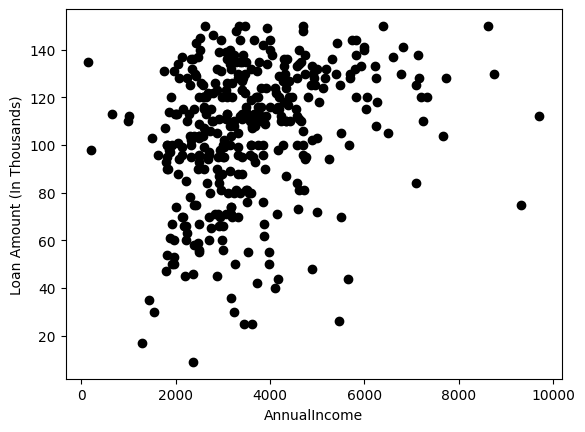

In [4]:
X = data[["LoanAmount","ApplicantIncome"]]
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.xlabel('AnnualIncome')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()

Ми побачили «хмару» чорних точок на площині. Кожна точка — це клієнт. По горизонталі — його річний дохід, по вертикалі — сума позики, яку він хоче отримати. На цьому етапі дані ще не розділені на групи.

## Вибір початкових центроїдів

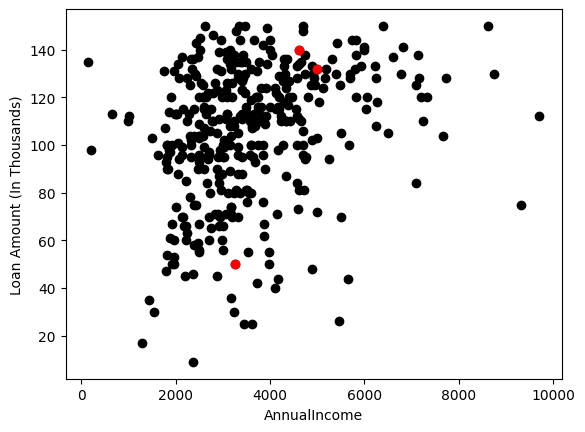

In [5]:
K=3
# Select random observation as centroids
Centroids = (X.sample(n=K))
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.scatter(Centroids["ApplicantIncome"],Centroids["LoanAmount"],c='red')
plt.xlabel('AnnualIncome')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()

На графіку з'явилися 3 червоні точки. Це наші початкові центри. Оскільки вони обрані випадково, вони можуть знаходитися в будь-якій частині графіка.

## Алгоритм кластеризації (K-means)

In [9]:
import warnings
warnings.filterwarnings('ignore')

diff = 1
j = 0

while(diff != 0):
    XD = X.copy()
    i = 1
    # Крок 3: Рахуємо відстань до кожного центроїда
    for index1, row_c in Centroids.iterrows():
        ED = []
        for index2, row_d in XD.iterrows():
            d1 = (row_c["ApplicantIncome"] - row_d["ApplicantIncome"])**2
            d2 = (row_c["LoanAmount"] - row_d["LoanAmount"])**2
            d = np.sqrt(d1 + d2)
            ED.append(d)
        X[i] = ED
        i = i + 1

    C = []
    # Призначаємо точку до найближчого центроїда
    for index, row in X.iterrows():
        min_dist = row[1]
        pos = 1
        for i in range(K):
            if row[i+1] < min_dist:
                min_dist = row[i+1]
                pos = i+1
        C.append(pos)
    X["Cluster"] = C

    # Крок 4: Обчислюємо нові центроїди
    Centroids_new = X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]

    if j == 0:
        diff = 1
        j = j + 1
    else:
        # Рахуємо різницю між старими та новими центроїдами
        diff = (Centroids_new['LoanAmount'] - Centroids['LoanAmount']).sum() + \
               (Centroids_new['ApplicantIncome'] - Centroids['ApplicantIncome']).sum()
        print(f"Iteration {j}, Difference: {diff}")
        j = j + 1

    Centroids = X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]

Iteration 1, Difference: 125.0623447088507
Iteration 2, Difference: -83.1630963024794
Iteration 3, Difference: -105.21413401624646
Iteration 4, Difference: -65.69290675004886
Iteration 5, Difference: -55.778909234822066
Iteration 6, Difference: -55.03495831127759
Iteration 7, Difference: -9.190752402517077
Iteration 8, Difference: -9.19844100901777
Iteration 9, Difference: -9.237706177129652
Iteration 10, Difference: 0.0


Програма вивела значення diff для кожної ітерації. Видно, як з кожним кроком різниця зменшується. Коли вона стала 0.0, це означає, що центроїди стабілізувалися і навчання моделі завершено.

## Фінальна візуалізація кластерів

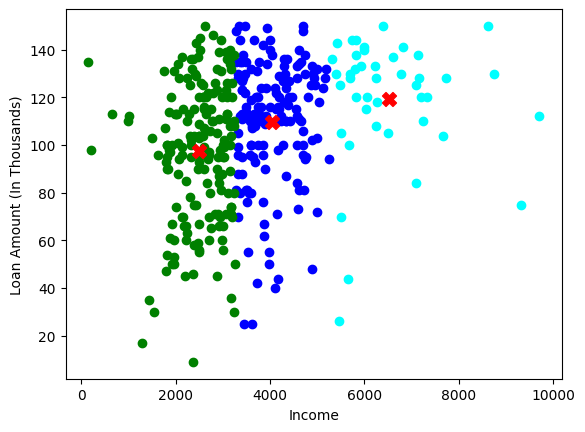

In [10]:
color = ['blue', 'green', 'cyan']
for k in range(K):
    cluster_data = X[X["Cluster"] == k + 1]
    plt.scatter(cluster_data["ApplicantIncome"], cluster_data["LoanAmount"], c=color[k])

plt.scatter(Centroids["ApplicantIncome"], Centroids["LoanAmount"], c='red', marker='X', s=100)
plt.xlabel('Income')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()

Ми отримали три чіткі групи клієнтів, позначені різними кольорами (синій, зелений, блакитний). Червоні хрестики — це фінальні центри цих груп.

Група 1: Клієнти з низьким доходом і низькою сумою позики.

Група 2: Клієнти з середнім доходом.

Група 3: "Багаті" клієнти з високим доходом та великими запитами на позику.

Це допомагає банку сегментувати аудиторію та пропонувати різні умови для кожної групи.

# Частина 2




## Імпорт бібліотек та завантаження даних

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans

In [12]:
data=pd.read_csv("Wholesale customers data.csv")
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Вивелася таблиця з першими 5 рядками. Ми бачимо витрати клієнтів (у грошових одиницях) на різні категорії товарів: свіжі продукти (Fresh), молоко (Milk), бакалію (Grocery) тощо. Також є категорії Channel (канал збуту) та Region (регіон).

## Аналіз статистики

In [13]:
data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Метод describe() вивів описову статистику (середнє значення, мінімум, максимум). Можна побачити, що масштаб даних дуже різний: максимальне значення для колонки Channel — 2, а для Fresh — понад 112 тисяч. Оскільки K-Means шукає відстані між точками, такі великі числа "перетягнуть" на себе всю увагу алгоритму.

## Стандартизація даних

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pd.DataFrame(data_scaled).describe()

,0,1,2,3,4,5,6,7
count,4.400000e+02,4.400000e+02,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,1.614870e-17,3.552714e-16,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-6.902971e-01,-1.995342e+00,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-6.902971e-01,-7.023369e-01,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-6.902971e-01,5.906683e-01,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,1.448652e+00,5.906683e-01,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,1.448652e+00,5.906683e-01,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


Тепер усі змінні приведені до однакового масштабу. Середнє значення (mean) для всіх колонок стало дуже близьким до 0, а стандартне відхилення (std) дорівнює 1. Тепер жодна категорія продуктів не буде домінувати над іншими просто через те, що там більші цифри.

## Перша модель та інерція

In [15]:
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(data_scaled)

kmeans.inertia_

2600.3756482224435

Ми отримали числове значення інерції (близько 2600). Інерція — це сума квадратів відстаней від кожної точки до центру її кластера. Чим менше це число, тим щільніші кластери і тим краще вони сформовані.

## Метод ліктя (Elbow Method)

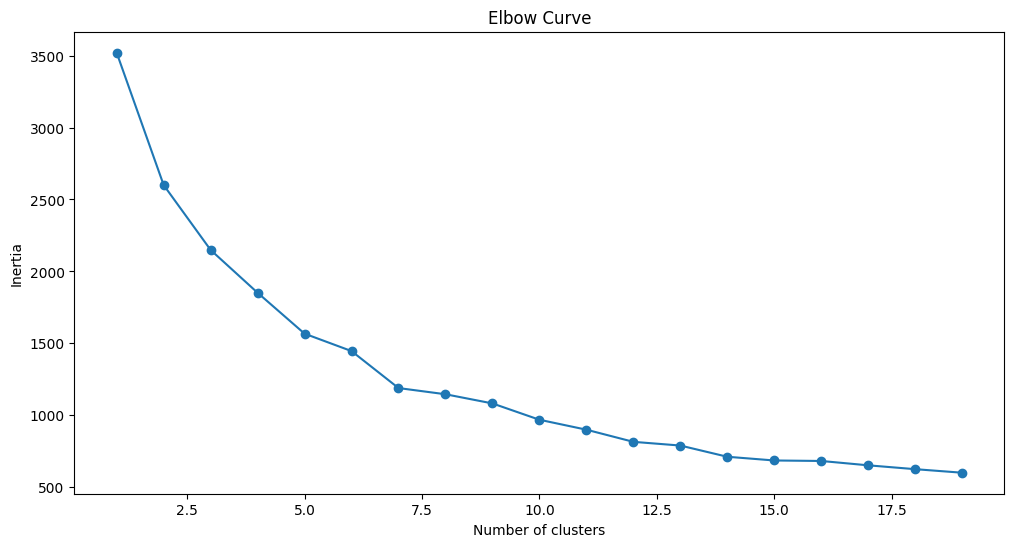

In [17]:
SSE = []
for cluster in range(1, 20):

    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    SSE.append(kmeans.inertia_)

frame = pd.DataFrame({'Cluster':range(1, 20), 'SSE':SSE})
plt.figure(figsize=(12, 6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

Отримали графік залежності інерції від кількості кластерів. Спочатку крива стрімко падає, а потім починає вирівнюватися. Місце згину (той самий "лікоть") підказує оптимальну кількість кластерів. За графіком видно, що оптимальне число кластерів знаходиться в діапазоні від 5 до 8, оскільки після 5 спад стає значно повільнішим.

## Фінальна кластеризація (K=5) та підрахунок точок

In [18]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(data_scaled)
pred = kmeans.predict(data_scaled)

frame = pd.DataFrame(data_scaled)
frame['cluster'] = pred
frame['cluster'].value_counts()

,count
cluster,
1,200
0,126
3,90
4,14
2,10


Результат: Функція value_counts() вивела 5 рядків із номерами кластерів (від 0 до 4) і кількістю клієнтів у кожному з них. (Наприклад, один кластер може містити близько 200 клієнтів, інший 126, а деякі — лише по 10-14).
Пояснення: З 440 оптових клієнтів алгоритм сформував 5 різних груп. Великі кластери — це типові покупці зі стандартними потребами. Кластери з малою кількістю точок (наприклад, 10) — це специфічні клієнти (можливо, великі ресторани або супермаркети), які купують аномально багато свіжих продуктів чи іншої специфічної категорії. Такий поділ дозволяє дистриб'ютору адаптувати рекламу та знижки окремо для кожної групи.

# Висновки до лабораторної роботи:
У ході виконання лабораторної роботи ми на практиці ознайомилися з алгоритмом машинного навчання без нагляду — кластеризацією методом K-Means. На прикладі двох датасетів (клієнти банку та оптові покупці) ми навчилися:


1.   Завантажувати та попередньо обробляти дані за допомогою pandas.
2.   Стандартизувати ознаки за допомогою StandardScaler, щоб уникнути домінування змінних з великими значеннями.
3.   Визначати оптимальну кількість кластерів за допомогою графічного "методу ліктя" (Elbow Method).
4.   Розбивати дані на сегменти та візуалізувати отримані результати за допомогою matplotlib.


Отримані навички дозволяють автоматично сегментувати клієнтів для бізнес-аналітики, наприклад, для персоналізації кредитної політики банку або формування цільових пропозицій для оптових покупців.

# Питання до самоперевірки

1. Що таке кластеризація? Які властивості кластерів ви знаєте?
Кластеризація — це процес групування об'єктів так, щоб об'єкти в одній групі (кластері) були максимально схожі між собою, а об'єкти з різних груп — максимально відрізнялися. Основні властивості: висока внутрішньокластерна щільність (подібність) та низька міжкластерна подібність.

2. Кластеризація відноситься до задач машинного навчання без нагляду (Unsupervised learning) чи це контроловане навчання (Supervised learning)?
Це навчання без нагляду (Unsupervised learning). У нас немає правильних відповідей (розмічених міток) заздалегідь, алгоритм сам шукає приховані закономірності та структуру в даних.

3. Які методи та алгоритми кластеризації ви знаєте?
Центроїдні (K-Means), щільнісні (DBSCAN), ієрархічні (Агломеративна кластеризація) та модельно-орієнтовані (Gaussian Mixture Models).

4. Наведіть приклади ієрархічних, щільнісних та ітеративних методів кластеризації, їх переваги та недоліки.

Ієрархічні (Agglomerative): Переваги — не треба заздалегідь знати кількість кластерів, будує наочне дерево (дендрограму). Недоліки — дуже повільно працює на великих обсягах даних.

Щільнісні (DBSCAN): Переваги — знаходить кластери будь-якої складної форми, добре відфільтровує шум (викиди). Недоліки — важко налаштувати параметри, погано працює, якщо кластери мають різну щільність.

Ітеративні (K-Means): Переваги — швидкий і простий у реалізації. Недоліки — потрібно вгадувати кількість кластерів заздалегідь, знаходить лише сферичні кластери, чутливий до викидів.

5. Які застосування кластеризації в реальних сценаріях ви знаєте?
Маркетингова сегментація клієнтів (як у цій лабі), рекомендаційні системи (пошук схожих товарів або фільмів), виявлення шахрайства (аномалій), стиснення зображень (зменшення кількості кольорів), аналіз соціальних мереж (пошук спільнот).

6. Які метрики оцінки кластеризації ви знаєте?
Оскільки правильних відповідей немає, використовують внутрішні метрики: Інерція (Inertia або WCSS — сума квадратів відстаней до центрів), Коефіцієнт силуету (Silhouette Score) та Індекс Девіса-Болдіна (Davies-Bouldin Index).

7. Що таке кластеризація K-Means? Як вибрати потрібну кількість кластерів у K-Means?
Це алгоритм, який розбиває дані на K груп, мінімізуючи відстань від точок до центру їхнього кластера (центроїда). Кількість кластерів найчастіше вибирають за допомогою "Методу ліктя" (Elbow method), будуючи графік інерції і шукаючи точку, де стрімке падіння графіка сповільнюється ("згин ліктя").

8. Для чого використовується алгоритм K-Means ++?
Це покращена версія ініціалізації звичайного K-Means. Замість того, щоб обирати початкові центри абсолютно випадково, K-Means++ розкидає їх якомога далі один від одного. Це дозволяє алгоритму працювати швидше та знаходити кращі, більш стабільні кластери.

9. Як реалізувати алгоритм кластеризації K-Means та алгоритм K-Means ++ у Python?
Використати бібліотеку scikit-learn: from sklearn.cluster import KMeans.
Для звичайного: KMeans(n_clusters=3, init='random').
Для K-Means++: KMeans(n_clusters=3, init='k-means++').

10. Для чого використовується стандартизація даних?
Щоб привести всі змінні до одного масштабу. Алгоритми кластеризації вимірюють відстані між точками. Якщо одна колонка має значення в одиницях (наприклад, вік 20-50), а інша — в тисячах (дохід 10000-50000), змінна з великими числами повністю перекриє вплив меншої.

11. Як реалізувати у Python стандартизацію даних?
За допомогою класу StandardScaler з пакету sklearn.preprocessing:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

12. Для чого використовуються пакети Python: pandas, numpy, matplotlib, random?

pandas — для зручної роботи з табличними даними (читання CSV, фільтрація, аналіз).

numpy — для швидких математичних обчислень та роботи з масивами/матрицями.

matplotlib — для побудови графіків та візуалізації даних.

random — для генерації випадкових чисел (наприклад, випадкового вибору центроїдів).

13. Які методи Python використовуются для прочитання файлу у форматі CSV та перегляду перших п’яти рядків даних?
Для читання: pd.read_csv('ім_я_файлу.csv')
Для перегляду перших 5 рядків: data.head()

14. Як реалізувати у Python ініціалізацію центроїдів кластера та побудувати криву ліктя?

Потрібно створити цикл (наприклад, від 1 до 20), у кожній ітерації створювати модель KMeans із відповідною кількістю кластерів, тренувати її та зберігати значення інерції (kmeans.inertia_) у пустий список. Після циклу цей список передається у plt.plot() для побудови графіка.